# 09 — Évaluation des Modèles sur un Jeu de Test Personnalisé

Ce notebook permet de **tester les meilleurs modèles entraînés** (ML classique, MLP, CNN) sur un fichier de test que vous fournissez.

## Formats supportés
CSV | JSON | JSONL

## Modèles testés
| Modèle | Fichier(s) | Tâche(s) |
|--------|-----------|----------|
| TF-IDF + LogReg | `polarity_tfidf_svm.pkl` / `rating_tfidf_logreg` | Polarité + Rating |
| MLP (TF-IDF) | `mlp_tfidf_pol.pt` / `mlp_tfidf_rat.pt` | Polarité + Rating |
| CNN | `cnn_pol.pt` / `cnn_rat.pt` | Polarité + Rating |

## Colonnes attendues dans le fichier
- **`text`** (configurable) : texte de la review
- **`stars`** (optionnel, configurable) : note 1–5 → permet de calculer les métriques d'évaluation

## Configuration

In [10]:
TEST_FILE = '../data/raw/test.jsonl'

TEXT_COL = 'text'

LABEL_COL = 'stars'

N_SAMPLES = None

BATCH_SIZE = 256

MODELS_DIR = '../models'
PRECOMPUTED_DIR = '../data/precomputed'

## Imports et initialisation

In [11]:
import sys
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, '..')
from src.models import MLP, TextCNN
from src.utils import clean_text, create_polarity_label, load_json_lines, add_polarity_column

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Fonctions utilitaires

In [12]:
# ---------------------------------------------------------------------------
# Chargement des données
# ---------------------------------------------------------------------------

def load_test_file(path, text_col, n_samples=None):
    """Charge un fichier CSV, JSON ou JSONL en DataFrame."""
    ext = os.path.splitext(path)[1].lower()

    if ext == '.csv':
        df = pd.read_csv(path, nrows=n_samples)
    elif ext == '.json':
        df = pd.read_json(path)
        if n_samples:
            df = df.head(n_samples)
    elif ext == '.jsonl':
        df = load_json_lines(path, n_lines=n_samples)
    else:
        raise ValueError(
            f'Format non supporté : "{ext}". Utilisez .csv, .json ou .jsonl'
        )

    if text_col not in df.columns:
        raise ValueError(
            f'Colonne "{text_col}" introuvable. '
            f'Colonnes disponibles : {list(df.columns)}'
        )
    return df


# ---------------------------------------------------------------------------
# Tokenisation pour CNN
# ---------------------------------------------------------------------------

def text_to_sequence(text, vocab, max_len=100):
    """Convertit un texte en séquence d'indices avec padding à droite.
    Tokens inconnus → index 1 (<UNK>), padding → index 0 (<PAD>).
    """
    tokens = text.split()
    indices = [vocab.get(w, 1) for w in tokens[:max_len]]
    indices += [0] * (max_len - len(indices))
    return indices


# ---------------------------------------------------------------------------
# Datasets PyTorch
# ---------------------------------------------------------------------------

class SparseDataset(Dataset):
    """Dataset pour matrices TF-IDF sparse → convertit en dense à la volée."""

    def __init__(self, sparse_matrix, labels=None):
        self.matrix = sparse_matrix.tocsr()
        self.labels = labels  # torch.Tensor long ou None

    def __len__(self):
        return self.matrix.shape[0]

    def __getitem__(self, idx):
        row = torch.tensor(
            self.matrix[idx].toarray().squeeze(0), dtype=torch.float32
        )
        lbl = (
            self.labels[idx]
            if self.labels is not None
            else torch.tensor(-1, dtype=torch.long)
        )
        return row, lbl


class DenseDataset(Dataset):
    """Dataset pour séquences CNN (indices entiers)."""

    def __init__(self, sequences, labels=None):
        self.seqs = torch.tensor(sequences, dtype=torch.long)
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        lbl = (
            self.labels[idx]
            if self.labels is not None
            else torch.tensor(-1, dtype=torch.long)
        )
        return self.seqs[idx], lbl


# ---------------------------------------------------------------------------
# Inférence PyTorch
# ---------------------------------------------------------------------------

def infer_dl(model, loader, device, label_classes, display_name, task_name, has_labels):
    """
    Inférence sur un modèle PyTorch.

    - has_labels=True  : calcule accuracy / F1, affiche matrice de confusion.
    - has_labels=False : affiche la distribution des prédictions.

    Retourne toujours (pred_labels, metrics_dict_or_None).
    pred_labels est une liste de valeurs lisibles (ex: 'positive', 3).
    """
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            if has_labels:
                all_true.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    pred_labels = [label_classes[i] for i in all_preds]

    print(f'\n{"="*55}')
    print(f'  {display_name}')
    print(f'{"="*55}')

    if not has_labels:
        dist = pd.Series(pred_labels).value_counts().sort_index()
        print('Distribution des prédictions :')
        print(dist.to_string())
        return pred_labels, None

    all_true = np.array(all_true)
    acc = accuracy_score(all_true, all_preds)
    f1m = f1_score(all_true, all_preds, average='macro')
    f1w = f1_score(all_true, all_preds, average='weighted')

    print(f'Accuracy    : {acc:.4f}')
    print(f'F1-macro    : {f1m:.4f}')
    print(f'F1-weighted : {f1w:.4f}')

    target_names = [str(c) for c in label_classes]
    print(f'\n{classification_report(all_true, all_preds, target_names=target_names)}')

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matrice de confusion — {display_name}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

    return pred_labels, {
        'Modèle': display_name,
        'Tâche': task_name,
        'Accuracy': round(acc, 4),
        'F1-macro': round(f1m, 4),
        'F1-weighted': round(f1w, 4),
    }


## Chargement et prétraitement des données

In [ ]:
print(f'Chargement : {TEST_FILE}')
df = load_test_file(TEST_FILE, TEXT_COL, N_SAMPLES)
print(f'  → {len(df):,} reviews chargées')

# Détection automatique des labels
HAS_LABELS = LABEL_COL is not None and LABEL_COL in df.columns

if HAS_LABELS:
    df = df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(float).astype(int)
    # Ajout automatique de la colonne polarite si absente
    if 'polarite' not in df.columns:
        df = add_polarity_column(df, rating_column=LABEL_COL)
    print(f'\nDistribution des ratings :')
    print(df[LABEL_COL].value_counts().sort_index().to_string())
    print(f'\nDistribution des polarités :')
    print(df['polarite'].value_counts().to_string())
else:
    df = df.dropna(subset=[TEXT_COL]).copy()
    if LABEL_COL is not None and LABEL_COL not in df.columns:
        print(f'  Colonne "{LABEL_COL}" non trouvée → mode prédiction uniquement')
    else:
        print(f'  → Aucun label (LABEL_COL=None) → mode prédiction uniquement')

# Nettoyage du texte
df['text_clean'] = df[TEXT_COL].apply(lambda x: clean_text(str(x)))



Chargement : ../data/raw/test.jsonl
  → 12 reviews chargées

Distribution des ratings :
stars
1    3
2    2
3    3
4    2
5    2

Distribution des polarités :
polarite
negative    5
positive    4
neutral     3


,text,text_clean,stars,polarite
0,Absolutely amazing experience from start to fi...,absolutely amazing experience from start to fi...,5,positive
1,I cannot say enough good things about this pla...,i cannot say enough good things about this pla...,5,positive
2,Really enjoyed our dinner here. The food was d...,really enjoyed our dinner here. the food was d...,4,positive


## Extraction des features

In [14]:
texts = df['text_clean'].tolist()

# --- TF-IDF ---
print('Vectorisation TF-IDF...')
with open(f'{PRECOMPUTED_DIR}/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vec = pickle.load(f)
X_tfidf = tfidf_vec.transform(texts)
print(f'Shape : {X_tfidf.shape}')

# --- Séquences CNN ---
print('\nTokenisation CNN...')
with open(f'{MODELS_DIR}/cnn_vocab.pkl', 'rb') as f:
    cnn_vocab = pickle.load(f)
MAX_SEQ_LEN = 100
X_seq = np.array([text_to_sequence(t, cnn_vocab, MAX_SEQ_LEN) for t in texts])
print(f'Shape : {X_seq.shape}')

# --- Encodage des labels (si présents) ---
POL_CLASSES = ['negative', 'neutral', 'positive']
RAT_CLASSES = [1, 2, 3, 4, 5]

if HAS_LABELS:
    le_pol = LabelEncoder()
    le_pol.fit(POL_CLASSES)
    y_pol = torch.tensor(
        le_pol.transform(df['polarite'].values), dtype=torch.long
    )

    le_rat = LabelEncoder()
    le_rat.fit(RAT_CLASSES)
    y_rat = torch.tensor(
        le_rat.transform(df[LABEL_COL].values), dtype=torch.long
    )

    print(f'\nClasses polarité encodées : {list(le_pol.classes_)}')
    print(f'Classes rating encodées   : {list(le_rat.classes_)}')
else:
    y_pol = None
    y_rat = None

all_results = []

print('\nExtraction des features terminée.')

Vectorisation TF-IDF...
Shape : (12, 5000)

Tokenisation CNN...
Shape : (12, 100)

Classes polarité encodées : [np.str_('negative'), np.str_('neutral'), np.str_('positive')]
Classes rating encodées   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Extraction des features terminée.


---
## 1. ML Classique

| Modèle | Fichier | Tâche |
|--------|---------|-------|
| TF-IDF + SVM | `polarity_tfidf_svm.pkl` | Polarité (3 classes) |
| TF-IDF + LogReg | `rating_tfidf_logreg.pkl` | Rating (5 classes) |

Chargement TF-IDF + SVM (Polarité)...

  TF-IDF + SVM (Polarité)
Accuracy    : 0.8333
F1-macro    : 0.7778
F1-weighted : 0.8056

              precision    recall  f1-score   support

    negative       0.71      1.00      0.83         5
     neutral       1.00      0.33      0.50         3
    positive       1.00      1.00      1.00         4

    accuracy                           0.83        12
   macro avg       0.90      0.78      0.78        12
weighted avg       0.88      0.83      0.81        12



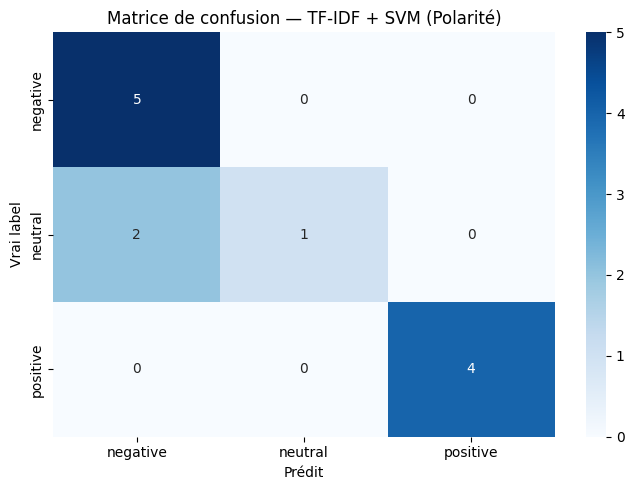


Chargement TF-IDF + LogReg (Rating)...

  TF-IDF + LogReg (Rating)
Accuracy    : 1.0000
F1-macro    : 1.0000
F1-weighted : 1.0000

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



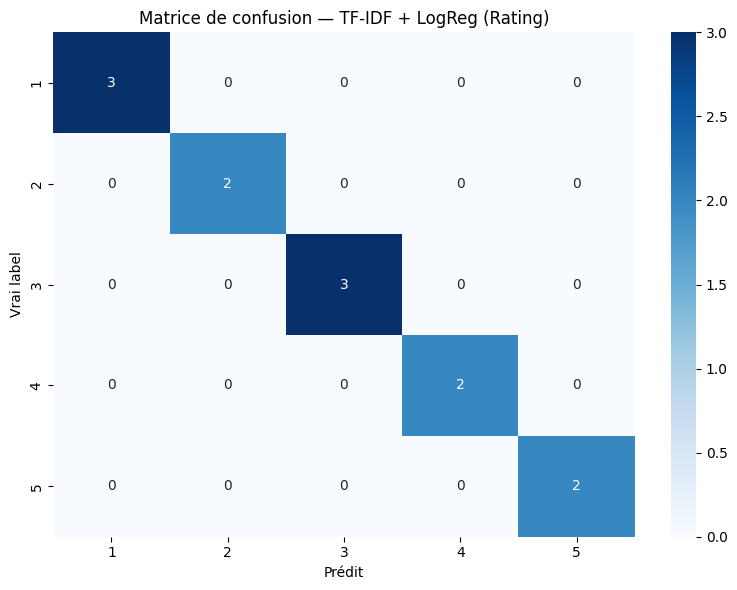

In [15]:
# --- Polarité : TF-IDF + SVM ---
print('Chargement TF-IDF + SVM (Polarité)...')
with open(f'{MODELS_DIR}/polarity_tfidf_svm.pkl', 'rb') as f:
    svm_pol = pickle.load(f)

y_pred_svm_pol = svm_pol.predict(X_tfidf)
df['pred_svm_pol'] = y_pred_svm_pol

print(f'\n{"="*55}')
print('  TF-IDF + SVM (Polarité)')
print(f'{"="*55}')

if HAS_LABELS:
    y_true_pol = df['polarite'].values
    acc = accuracy_score(y_true_pol, y_pred_svm_pol)
    f1m = f1_score(y_true_pol, y_pred_svm_pol, average='macro')
    f1w = f1_score(y_true_pol, y_pred_svm_pol, average='weighted')

    print(f'Accuracy    : {acc:.4f}')
    print(f'F1-macro    : {f1m:.4f}')
    print(f'F1-weighted : {f1w:.4f}')
    print(f'\n{classification_report(y_true_pol, y_pred_svm_pol)}')

    cm = confusion_matrix(y_true_pol, y_pred_svm_pol, labels=POL_CLASSES)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=POL_CLASSES, yticklabels=POL_CLASSES)
    plt.title('Matrice de confusion — TF-IDF + SVM (Polarité)')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

    all_results.append({
        'Modèle': 'TF-IDF + SVM',
        'Tâche': 'Polarité',
        'Accuracy': round(acc, 4),
        'F1-macro': round(f1m, 4),
        'F1-weighted': round(f1w, 4),
    })
else:
    print('Distribution des prédictions :')
    print(pd.Series(y_pred_svm_pol).value_counts().sort_index().to_string())

# --- Rating : TF-IDF + LogReg ---
print('\nChargement TF-IDF + LogReg (Rating)...')
with open(f'{MODELS_DIR}/rating_tfidf_logreg.pkl', 'rb') as f:
    logreg_rat = pickle.load(f)

y_pred_logreg_rat = logreg_rat.predict(X_tfidf)
df['pred_logreg_rat'] = y_pred_logreg_rat

print(f'\n{"="*55}')
print('  TF-IDF + LogReg (Rating)')
print(f'{"="*55}')

if HAS_LABELS:
    y_true_rat = df[LABEL_COL].values
    acc = accuracy_score(y_true_rat, y_pred_logreg_rat)
    f1m = f1_score(y_true_rat, y_pred_logreg_rat, average='macro')
    f1w = f1_score(y_true_rat, y_pred_logreg_rat, average='weighted')

    print(f'Accuracy    : {acc:.4f}')
    print(f'F1-macro    : {f1m:.4f}')
    print(f'F1-weighted : {f1w:.4f}')
    print(f'\n{classification_report(y_true_rat, y_pred_logreg_rat)}')

    cm = confusion_matrix(y_true_rat, y_pred_logreg_rat, labels=RAT_CLASSES)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=RAT_CLASSES, yticklabels=RAT_CLASSES)
    plt.title('Matrice de confusion — TF-IDF + LogReg (Rating)')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

    all_results.append({
        'Modèle': 'TF-IDF + LogReg',
        'Tâche': 'Rating',
        'Accuracy': round(acc, 4),
        'F1-macro': round(f1m, 4),
        'F1-weighted': round(f1w, 4),
    })
else:
    print('Distribution des prédictions :')
    print(pd.Series(y_pred_logreg_rat).value_counts().sort_index().to_string())


---
## 2. MLP — Multi-Layer Perceptron (TF-IDF)

| Modèle | Fichier | Couches cachées | Classes |
|--------|---------|----------------|---------|
| MLP Polarité | `mlp_tfidf_pol.pt` | (256, 128) | 3 |
| MLP Rating | `mlp_tfidf_rat.pt` | (512, 256, 128) | 5 |

Features : TF-IDF (5 000 dimensions)

Chargement MLP TF-IDF (Polarité)...

  MLP TF-IDF (Polarité)
Accuracy    : 1.0000
F1-macro    : 1.0000
F1-weighted : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         5
     neutral       1.00      1.00      1.00         3
    positive       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



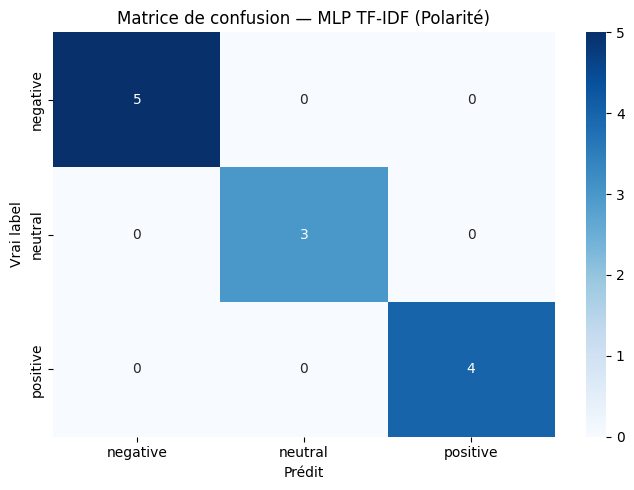


Chargement MLP TF-IDF (Rating)...

  MLP TF-IDF (Rating)
Accuracy    : 0.9167
F1-macro    : 0.9200
F1-weighted : 0.9167

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.67      1.00      0.80         2
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2

    accuracy                           0.92        12
   macro avg       0.93      0.93      0.92        12
weighted avg       0.94      0.92      0.92        12



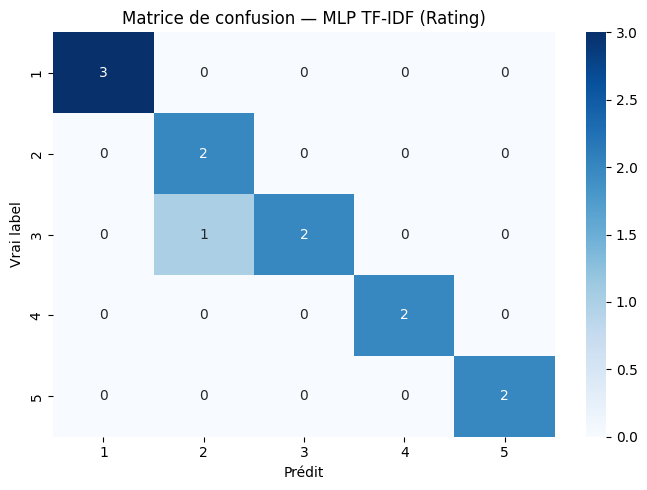


Colonnes ajoutées : "pred_mlp_pol", "pred_mlp_rat"


In [16]:
# DataLoaders TF-IDF
tfidf_pol_loader = DataLoader(
    SparseDataset(X_tfidf, y_pol), batch_size=BATCH_SIZE, shuffle=False
)
tfidf_rat_loader = DataLoader(
    SparseDataset(X_tfidf, y_rat), batch_size=BATCH_SIZE, shuffle=False
)

# --- MLP Polarité ---
print('Chargement MLP TF-IDF (Polarité)...')
mlp_pol = MLP(input_dim=5000, n_classes=3, hidden_dims=(256, 128), dropout=0.5)
mlp_pol.load_state_dict(
    torch.load(f'{MODELS_DIR}/mlp_tfidf_pol.pt', map_location=device)
)
mlp_pol.to(device)

preds, metrics = infer_dl(
    mlp_pol, tfidf_pol_loader, device,
    POL_CLASSES, 'MLP TF-IDF (Polarité)', 'Polarité', HAS_LABELS
)
df['pred_mlp_pol'] = preds
if metrics:
    all_results.append(metrics)

# --- MLP Rating ---
print('\nChargement MLP TF-IDF (Rating)...')
mlp_rat = MLP(input_dim=5000, n_classes=5, hidden_dims=(512, 256, 128), dropout=0.5)
mlp_rat.load_state_dict(
    torch.load(f'{MODELS_DIR}/mlp_tfidf_rat.pt', map_location=device)
)
mlp_rat.to(device)

preds, metrics = infer_dl(
    mlp_rat, tfidf_rat_loader, device,
    RAT_CLASSES, 'MLP TF-IDF (Rating)', 'Rating', HAS_LABELS
)
df['pred_mlp_rat'] = preds
if metrics:
    all_results.append(metrics)

print('\nColonnes ajoutées : "pred_mlp_pol", "pred_mlp_rat"')


---
## 3. CNN — TextCNN

| Modèle | Fichier | Vocab | Embed | Filtres | Classes |
|--------|---------|-------|-------|---------|----------|
| CNN Polarité | `cnn_pol.pt` | 10 002 | 64 | 64 × (3,4,5) | 3 |
| CNN Rating | `cnn_rat.pt` | 10 002 | 64 | 64 × (3,4,5) | 5 |

Features : séquences tokenisées (longueur max = 100 tokens)

Chargement CNN (Polarité)...

  CNN (Polarité)
Accuracy    : 0.9167
F1-macro    : 0.9030
F1-weighted : 0.9121

              precision    recall  f1-score   support

    negative       0.83      1.00      0.91         5
     neutral       1.00      0.67      0.80         3
    positive       1.00      1.00      1.00         4

    accuracy                           0.92        12
   macro avg       0.94      0.89      0.90        12
weighted avg       0.93      0.92      0.91        12



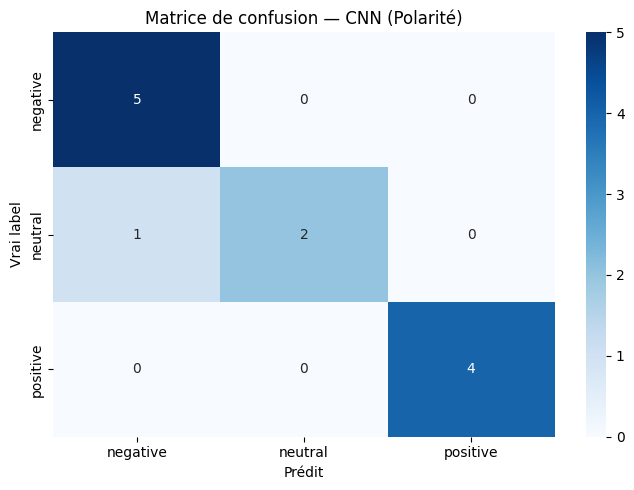


Chargement CNN (Rating)...

  CNN (Rating)
Accuracy    : 0.9167
F1-macro    : 0.9200
F1-weighted : 0.9167

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.67      1.00      0.80         2
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2

    accuracy                           0.92        12
   macro avg       0.93      0.93      0.92        12
weighted avg       0.94      0.92      0.92        12



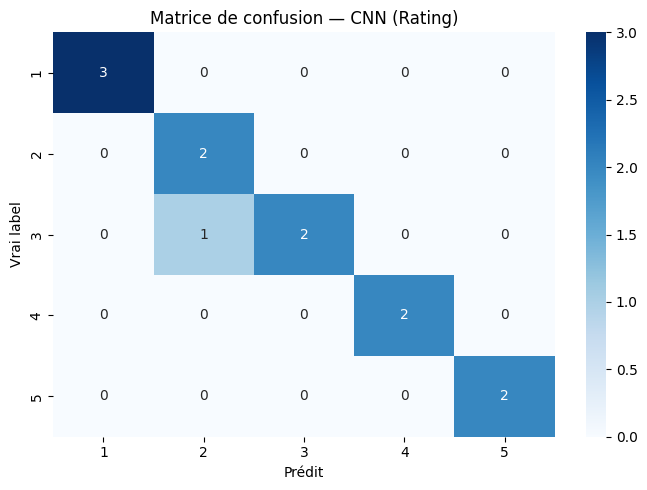


Colonnes ajoutées : "pred_cnn_pol", "pred_cnn_rat"


In [17]:
cnn_pol_loader = DataLoader(
    DenseDataset(X_seq, y_pol), batch_size=BATCH_SIZE, shuffle=False
)
cnn_rat_loader = DataLoader(
    DenseDataset(X_seq, y_rat), batch_size=BATCH_SIZE, shuffle=False
)

CNN_KWARGS = dict(
    vocab_size=10002, embed_dim=64,
    n_filters=64, filter_sizes=(3, 4, 5), dropout=0.5
)

# --- CNN Polarité ---
print('Chargement CNN (Polarité)...')
cnn_pol = TextCNN(n_classes=3, **CNN_KWARGS)
cnn_pol.load_state_dict(
    torch.load(f'{MODELS_DIR}/cnn_pol.pt', map_location=device)
)
cnn_pol.to(device)

preds, metrics = infer_dl(
    cnn_pol, cnn_pol_loader, device,
    POL_CLASSES, 'CNN (Polarité)', 'Polarité', HAS_LABELS
)
df['pred_cnn_pol'] = preds
if metrics:
    all_results.append(metrics)

# --- CNN Rating ---
print('\nChargement CNN (Rating)...')
cnn_rat = TextCNN(n_classes=5, **CNN_KWARGS)
cnn_rat.load_state_dict(
    torch.load(f'{MODELS_DIR}/cnn_rat.pt', map_location=device)
)
cnn_rat.to(device)

preds, metrics = infer_dl(
    cnn_rat, cnn_rat_loader, device,
    RAT_CLASSES, 'CNN (Rating)', 'Rating', HAS_LABELS
)
df['pred_cnn_rat'] = preds
if metrics:
    all_results.append(metrics)

print('\nColonnes ajoutées : "pred_cnn_pol", "pred_cnn_rat"')


---
## Comparaison des résultats & DataFrame de sortie

RÉCAPITULATIF DES RÉSULTATS
               Modèle    Tâche  Accuracy  F1-macro  F1-weighted
MLP TF-IDF (Polarité) Polarité    1.0000    1.0000       1.0000
       CNN (Polarité) Polarité    0.9167    0.9030       0.9121
         TF-IDF + SVM Polarité    0.8333    0.7778       0.8056
      TF-IDF + LogReg   Rating    1.0000    1.0000       1.0000
  MLP TF-IDF (Rating)   Rating    0.9167    0.9200       0.9167
         CNN (Rating)   Rating    0.9167    0.9200       0.9167


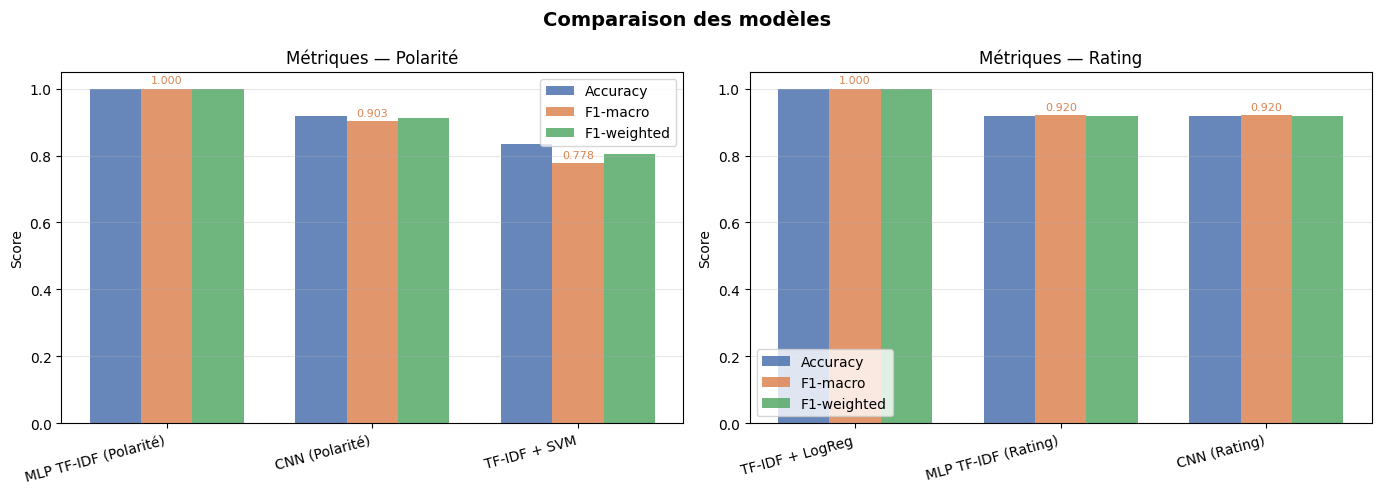


Meilleurs modèles par tâche (F1-macro) :
  Polarité   → MLP TF-IDF (Polarité)           Accuracy=1.0000  F1-macro=1.0000
  Rating     → TF-IDF + LogReg                 Accuracy=1.0000  F1-macro=1.0000

DATAFRAME DE SORTIE (avec prédictions)

Aperçu (12 lignes, 9 colonnes) :


,text,stars,polarite,pred_svm_pol,pred_logreg_rat,pred_mlp_pol,pred_mlp_rat,pred_cnn_pol,pred_cnn_rat
0,Absolutely amazing experience from start to fi...,5,positive,positive,5,positive,5,positive,5
1,I cannot say enough good things about this pla...,5,positive,positive,5,positive,5,positive,5
2,Really enjoyed our dinner here. The food was d...,4,positive,positive,4,positive,4,positive,4
3,"Great spot for lunch. Fresh ingredients, tasty...",4,positive,positive,4,positive,4,positive,4
4,Decent place but nothing special. The food was...,3,neutral,neutral,3,neutral,3,neutral,3
5,Mixed feelings about this restaurant. Some dis...,3,neutral,negative,3,neutral,2,neutral,3
6,Average experience overall. The burger was fin...,3,neutral,negative,3,neutral,3,negative,2
7,Pretty disappointing visit. We waited over 40 ...,2,negative,negative,2,negative,2,negative,2
8,Expected much more based on the reviews online...,2,negative,negative,2,negative,2,negative,2
9,Terrible experience from beginning to end. We ...,1,negative,negative,1,negative,1,negative,1


In [18]:
# ---------------------------------------------------------------------------
# Tableau comparatif (uniquement si labels disponibles)
# ---------------------------------------------------------------------------
if HAS_LABELS and all_results:
    df_res = pd.DataFrame(all_results)
    df_res = df_res.sort_values(['Tâche', 'F1-macro'], ascending=[True, False])

    print('=' * 70)
    print('RÉCAPITULATIF DES RÉSULTATS')
    print('=' * 70)
    print(df_res.to_string(index=False))

    tasks = df_res['Tâche'].unique().tolist()
    n_tasks = len(tasks)
    fig, axes = plt.subplots(1, n_tasks, figsize=(7 * n_tasks, 5))
    if n_tasks == 1:
        axes = [axes]

    width = 0.25
    metrics_cols = ['Accuracy', 'F1-macro', 'F1-weighted']
    colors = ['#4C72B0', '#DD8452', '#55A868']

    for ax, task in zip(axes, tasks):
        sub = df_res[df_res['Tâche'] == task].reset_index(drop=True)
        x = np.arange(len(sub))

        for i, (col, color) in enumerate(zip(metrics_cols, colors)):
            ax.bar(x + (i - 1) * width, sub[col], width,
                   label=col, color=color, alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(sub['Modèle'].tolist(), rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'Métriques — {task}', fontsize=12)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylabel('Score')

        for idx, row in sub.iterrows():
            ax.text(idx, row['F1-macro'] + 0.01, f"{row['F1-macro']:.3f}",
                    ha='center', va='bottom', fontsize=8, color='#DD8452')

    plt.suptitle('Comparaison des modèles', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nMeilleurs modèles par tâche (F1-macro) :')
    best = df_res.loc[df_res.groupby('Tâche')['F1-macro'].idxmax()]
    for _, row in best.iterrows():
        print(f"  {row['Tâche']:10s} → {row['Modèle']:30s}  "
              f"Accuracy={row['Accuracy']:.4f}  F1-macro={row['F1-macro']:.4f}")

elif not HAS_LABELS:
    print('Mode prédiction — pas de métriques disponibles.')
    print("Définissez LABEL_COL dans la configuration pour activer l'évaluation.\n")

# ---------------------------------------------------------------------------
# DataFrame de sortie avec toutes les prédictions
# ---------------------------------------------------------------------------
print('\n' + '=' * 70)
print('DATAFRAME DE SORTIE (avec prédictions)')
print('=' * 70)

pred_cols = [c for c in df.columns if c.startswith('pred_')]
base_cols = [TEXT_COL]
if HAS_LABELS:
    base_cols += [LABEL_COL, 'polarite']

if not HAS_LABELS:
    for best_pol_col in ['pred_cnn_pol', 'pred_mlp_pol', 'pred_svm_pol', 'pred_logreg_pol']:
        if best_pol_col in df.columns:
            df['polarite'] = df[best_pol_col]
            print(f'Colonne "polarite" ajoutée automatiquement depuis {best_pol_col}')
            base_cols.append('polarite')
            break

output_cols = base_cols + pred_cols
df_out = df[output_cols].copy()

print(f'\nAperçu ({len(df_out):,} lignes, {len(output_cols)} colonnes) :')
display(df_out.head(10))
